# Multi-seed × Multi-ticker — o teste de generalização

Roda o protocolo de 20 seeds nos **3 tickers** (ITUB4, PETR4, VALE3) para responder à pergunta mais perigosa da banca:

> *Você só teve sorte com uma ação?*

## Protocolo

Para cada ticker:
1. Carrega preços (`yfinance`, 5 anos) + sentimento FinBERT pré-computado.
2. Treina **Transformer + FinBERT** (16 features) com 20 seeds.
3. Treina **dumb baseline XGBoost** (5 features autoregressivas) com 20 seeds.
4. Coleta AUC, precision/recall por classe, n_down_calls.

## Padrões esperados

| Padrão observado | Conclusão |
|---|---|
| 3/3 tickers: Transformer mediana > baseline mediana com Δ ≥ 0.10 | Achado generaliza. Tese sólida sobre Brazilian large-caps. |
| 2/3 tickers seguem o padrão | Achado parcial. Discutir o ticker que falha (provavelmente regime/setor). |
| 1/3 (só ITUB4) | Bank-specific finding. Reduzir escopo da tese. |
| 0/3 ou padrão inverso | ITUB4 foi sorte. Pivotar para a história metodológica. |

**Tempo esperado em RTX 3050:** ~20-30 minutos para 120 trainings.

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import xgboost as xgb
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from eval_utils import walk_forward_split, make_binary_target

HORIZON = 21
WINDOW = 30
N_SEEDS = 20
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

TICKERS = {
    'ITUB4': ('ITUB4.SA', '../4.finbert-br/itub4_daily_sentiment.csv'),
    'PETR4': ('PETR4.SA', '../4.finbert-br/petr4_daily_sentiment.csv'),
    'VALE3': ('VALE3.SA', '../4.finbert-br/vale3_daily_sentiment.csv'),
}
PRICE_COLS = ['Close','Volume','return','ma7','ma21','std21','lag_1','lag_2','lag_3','lag_4','lag_5']
SENT_COLS  = ['n_articles','mean_logit_pos','mean_logit_neg','mean_logit_neu','mean_sentiment']
BASELINE_FEATURES = ['return','lag_1','lag_5','Volume','std21']
FULL_FEATURES = PRICE_COLS + SENT_COLS

device: cuda


## 1. Funções compartilhadas (build, métricas, modelos)

In [2]:
def load_prices(yf_ticker, period='5y'):
    df = yf.Ticker(yf_ticker).history(period=period, auto_adjust=True).reset_index()
    df['date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
    df = df[['date','Close','Volume']].copy()
    df['return'] = df['Close'].pct_change()
    df['ma7']    = df['Close'].rolling(7).mean()
    df['ma21']   = df['Close'].rolling(21).mean()
    df['std21']  = df['Close'].rolling(21).std()
    for k in range(1, 6):
        df[f'lag_{k}'] = df['Close'].shift(k)
    return df.dropna().reset_index(drop=True)

def build_dataset(yf_ticker, sentiment_csv):
    px = load_prices(yf_ticker)
    sent = pd.read_csv(sentiment_csv, parse_dates=['date'])[['date'] + SENT_COLS]
    df = px.merge(sent, on='date', how='left').sort_values('date').reset_index(drop=True)
    df[SENT_COLS] = df[SENT_COLS].ffill().fillna(0)
    df['target'] = make_binary_target(df['Close'], horizon=HORIZON)
    return df.dropna(subset=['target']).reset_index(drop=True)

def make_windows(X, y, window=WINDOW):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

def collect_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        'auc':         roc_auc_score(y_true, y_score),
        'prec_down':   precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'recall_down': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'prec_up':     precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_up':   recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'n_down_calls': int(cm[:, 0].sum()),
        'n_test':       int(len(y_true)),
    }

In [3]:
class Stage4Transformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, nlayers=2, window=WINDOW):
        super().__init__()
        self.proj = nn.Linear(n_features, d_model)
        pe = torch.zeros(window, d_model)
        pos = torch.arange(0, window).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos*div); pe[:, 1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=0.2, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=nlayers)
        self.head = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, 1))
    def forward(self, x):
        h = self.proj(x) + self.pe[:, :x.size(1), :]
        h = self.enc(h)
        return self.head(h.mean(dim=1)).squeeze(-1)

def train_transformer(df, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    train, val, test = walk_forward_split(df)
    sc = StandardScaler().fit(train[FULL_FEATURES])
    Xtr = sc.transform(train[FULL_FEATURES]); ytr = train['target'].values.astype(int)
    Xva = sc.transform(val[FULL_FEATURES]);   yva = val['target'].values.astype(int)
    Xte = sc.transform(test[FULL_FEATURES]);  yte = test['target'].values.astype(int)
    Xtw, ytw = make_windows(Xtr, ytr)
    Xvw, yvw = make_windows(Xva, yva)
    Xew, yew = make_windows(Xte, yte)

    model = Stage4Transformer(n_features=len(FULL_FEATURES)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    pos = (ytw==1).sum(); neg = (ytw==0).sum()
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg/max(pos,1)], device=device, dtype=torch.float32))

    Xt_t = torch.tensor(Xtw, dtype=torch.float32, device=device)
    yt_t = torch.tensor(ytw, dtype=torch.float32, device=device)
    Xv_t = torch.tensor(Xvw, dtype=torch.float32, device=device)
    yv_t = torch.tensor(yvw, dtype=torch.float32, device=device)
    Xe_t = torch.tensor(Xew, dtype=torch.float32, device=device)

    best=float('inf'); best_state=None; bad=0; patience=15
    for epoch in range(200):
        model.train(); opt.zero_grad()
        loss = loss_fn(model(Xt_t), yt_t); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(Xv_t), yv_t).item()
        if vl < best - 1e-4:
            best=vl; best_state={k:v.clone() for k,v in model.state_dict().items()}; bad=0
        else:
            bad += 1
            if bad >= patience: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        y_score = torch.sigmoid(model(Xe_t)).cpu().numpy()
    return collect_metrics(yew, y_score)

def train_baseline(df, seed):
    np.random.seed(seed)
    train, val, test = walk_forward_split(df)
    sc = StandardScaler().fit(train[BASELINE_FEATURES])
    Xtr = sc.transform(train[BASELINE_FEATURES]); ytr = train['target'].values.astype(int)
    Xva = sc.transform(val[BASELINE_FEATURES]);   yva = val['target'].values.astype(int)
    Xte = sc.transform(test[BASELINE_FEATURES]);  yte = test['target'].values.astype(int)
    pos = (ytr==1).sum(); neg = (ytr==0).sum()
    m = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg/max(pos,1), eval_metric='auc', random_state=seed,
    )
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    return collect_metrics(yte, m.predict_proba(Xte)[:,1])

## 2. Loop principal (3 tickers × 20 seeds × 2 modelos = 120 trainings)

In [4]:
rows = []
t0 = time.time()
for ticker, (yf_t, sent_csv) in TICKERS.items():
    print(f'\n=== {ticker} ===')
    df = build_dataset(yf_t, sent_csv)
    train, val, test = walk_forward_split(df)
    print(f'  dataset: {len(df)} dias | balance up = {df["target"].mean():.3f}')
    print(f'  train balance={train["target"].mean():.3f} | test balance={test["target"].mean():.3f}')
    for seed in range(N_SEEDS):
        rt = train_transformer(df, seed)
        rt['ticker']=ticker; rt['model']='transformer_finbert'; rt['seed']=seed; rows.append(rt)
        rb = train_baseline(df, seed)
        rb['ticker']=ticker; rb['model']='baseline_xgb'; rb['seed']=seed; rows.append(rb)
        if seed % 5 == 0 or seed == N_SEEDS-1:
            elapsed = time.time() - t0
            print(f'  seed {seed:2d} | trans AUC={rt["auc"]:.3f} | base AUC={rb["auc"]:.3f} | {elapsed:.0f}s')

results = pd.DataFrame(rows)
results.to_csv('results_multi_seed_multi_ticker.csv', index=False)
print(f'\nTotal: {len(results)} runs in {time.time()-t0:.0f}s')


=== ITUB4 ===


  dataset: 1207 dias | balance up = 0.587
  train balance=0.564 | test balance=0.681


  seed  0 | trans AUC=0.837 | base AUC=0.687 | 3s


  seed  5 | trans AUC=0.872 | base AUC=0.678 | 10s


  seed 10 | trans AUC=0.928 | base AUC=0.700 | 17s


...

  seed  0 | trans AUC=0.942 | base AUC=0.681 | 48s


  seed  5 | trans AUC=0.923 | base AUC=0.673 | 51s


  seed 10 | trans AUC=0.992 | base AUC=0.686 | 53s


  seed 15 | trans AUC=0.998 | base AUC=0.689 | 56s


  seed 19 | trans AUC=0.996 | base AUC=0.677 | 58s

Total: 120 runs in 58s


## 3. Tabela agregada — a tabela mais importante do TCC

In [5]:
agg = results.groupby(['ticker','model']).agg(
    auc_mean=('auc','mean'), auc_std=('auc','std'),
    auc_median=('auc','median'),
    auc_min=('auc','min'), auc_max=('auc','max'),
    prec_down_mean=('prec_down','mean'),
    n_down_mean=('n_down_calls','mean'),
    auc_above_065=('auc', lambda s: (s >= 0.65).sum()),
).round(3)
print(agg.to_string())
agg.to_csv('multi_seed_multi_ticker_summary.csv')

                            auc_mean  auc_std  auc_median  auc_min  auc_max  prec_down_mean  n_down_mean  auc_above_065
ticker model                                                                                                           
ITUB4  baseline_xgb            0.685    0.014       0.682    0.661    0.704           0.322       180.35             20
       transformer_finbert     0.695    0.256       0.801    0.093    0.928           0.291        87.80             15
PETR4  baseline_xgb            0.587    0.007       0.587    0.576    0.601           0.423       103.70              0
       transformer_finbert     0.345    0.052       0.334    0.252    0.468           0.318       120.80              0
VALE3  baseline_xgb            0.680    0.009       0.679    0.659    0.694           0.215       121.50             20
       transformer_finbert     0.922    0.135       0.992    0.534    0.998           0.287        81.85             18


In [6]:
# Pivot mediana: a única tabela que vai para a defesa
pivot_median = results.groupby(['ticker','model'])['auc'].median().unstack()
pivot_median['delta'] = pivot_median['transformer_finbert'] - pivot_median['baseline_xgb']
print('Mediana de AUC por (ticker, modelo):')
print(pivot_median.round(3).to_string())

wins = (pivot_median['delta'] > 0.05).sum()
print(f'\nTransformer mediana ≥ baseline + 0.05 em {wins}/3 tickers')

Mediana de AUC por (ticker, modelo):
model   baseline_xgb  transformer_finbert  delta
ticker                                          
ITUB4          0.682                0.801  0.119
PETR4          0.587                0.334 -0.253
VALE3          0.679                0.992  0.313

Transformer mediana ≥ baseline + 0.05 em 2/3 tickers


## 4. Visualização — distribuição de AUC por ticker

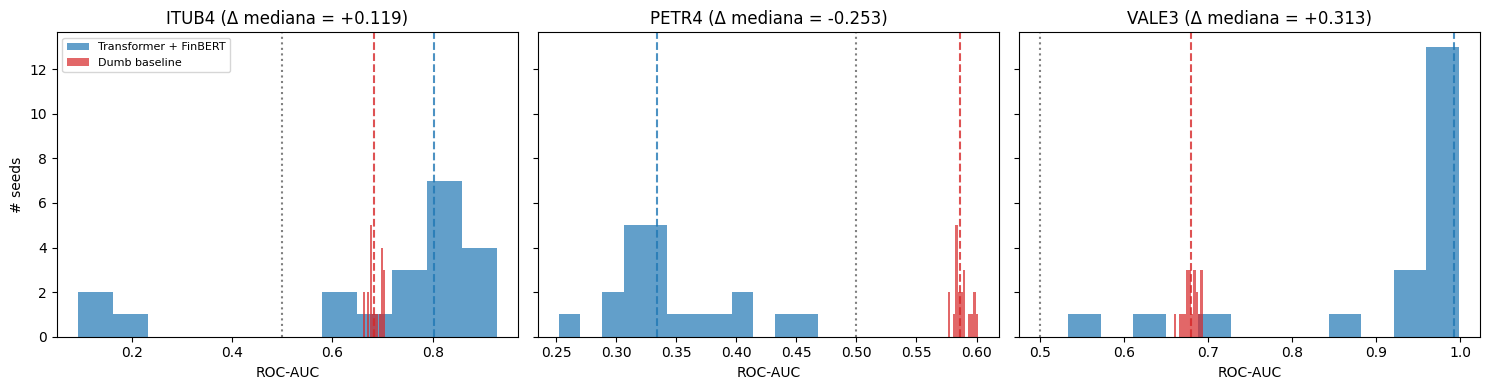

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (ticker, _) in zip(axes, TICKERS.items()):
    sub = results[results.ticker == ticker]
    tr = sub[sub.model=='transformer_finbert']['auc']
    ba = sub[sub.model=='baseline_xgb']['auc']
    ax.hist(tr, bins=12, alpha=0.7, label='Transformer + FinBERT', color='C0')
    ax.hist(ba, bins=12, alpha=0.7, label='Dumb baseline', color='C3')
    ax.axvline(0.5, ls=':', color='gray')
    ax.axvline(tr.median(), ls='--', color='C0', alpha=0.8)
    ax.axvline(ba.median(), ls='--', color='C3', alpha=0.8)
    ax.set_title(f'{ticker} (Δ mediana = {tr.median()-ba.median():+.3f})')
    ax.set_xlabel('ROC-AUC')
axes[0].set_ylabel('# seeds')
axes[0].legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('multi_seed_multi_ticker.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Decisão final

Conte quantos tickers têm `delta` > 0.05 (Transformer mediana bate baseline mediana por ≥ 5 pontos de AUC):

- **3/3** → Achado generaliza nos 3 large-caps brasileiros. Tese sólida. Próximo passo: regime split por volatilidade do IBOV.
- **2/3** → Discutir o ticker que falha. Pode ser explicado por setor (commodities vs banco) ou regime.
- **1/3** → Achado é específico de ITUB4. Reduzir escopo: "sentimento financeiro adiciona valor preditivo para o setor bancário".
- **0/3** → Pivotar a tese para a história metodológica (multi-seed, bimodal collapse, fragilidade de avaliação).